## Import lib

In [2]:

import pandas as pd 
import numpy as np 
import os
import sys
sys.path.append('../')
sys.path.append('../..')
import random

from sklearn.metrics import classification_report, confusion_matrix \
        , roc_auc_score, f1_score, accuracy_score, precision_score, recall_score

from preprocessing.load_data import DataLoader

In [3]:
from detection.isolation_forest import IsolationForestDetector
from detection.lof import LocalOutlierFactorDetector
from detection.autoencoder import AutoencoderDetector

## Read data

In [4]:
training_data_path = '..\\..\\data\\raw\\SMD_data_use\\ServerMachineDataset\\train'

test_data_path = '..\\..\\data\\raw\\SMD_data_use\\ServerMachineDataset\\test'
test_labels_path = '..\\..\\data\\raw\\SMD_data_use\\ServerMachineDataset\\test_label'

Link tham khao 1 bai anomaly voi bo data set nay: https://www.kaggle.com/code/imenbenamar1/anomalydetection-multivariate-time-series   

Trong code có cả cell đặt tên cho cột  

In [5]:
new_column_names = [
    'cpu_r', 'load_1', 'load_5', 'load_15', 'mem_shmem', 'mem_u', 'mem_u_e', 'total_mem',
    'disk_q', 'disk_r', 'disk_rb', 'disk_svc', 'disk_u', 'disk_w', 'disk_wa', 'disk_wb',
    'si', 'so', 'eth1_fi', 'eth1_fo', 'eth1_pi', 'eth1_po', 'tcp_tw', 'tcp_use',
    'active_opens', 'curr_estab', 'in_errs', 'in_segs', 'listen_overflows', 'out_rsts',
    'out_segs', 'passive_opens', 'retransegs', 'tcp_timeouts', 'udp_in_dg', 'udp_out_dg',
    'udp_rcv_buf_errs', 'udp_snd_buf_errs'
]

In [6]:
training_data = pd.read_csv(training_data_path + '\\machine-1-1.txt', header=None)
print("Training data shape: ", training_data.shape)

training_data.head(2)

Training data shape:  (28479, 38)


,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,36,37
0,0.032258,0.039195,0.027871,0.024390,0.0,0.915385,0.343691,0.0,0.020011,0.000122,...,0.0,0.004298,0.029993,0.022131,0.0,0.000045,0.034677,0.034747,0.0,0.0
1,0.043011,0.048729,0.033445,0.025552,0.0,0.915385,0.344633,0.0,0.019160,0.001722,...,0.0,0.004298,0.030041,0.028821,0.0,0.000045,0.035763,0.035833,0.0,0.0


In [7]:
training_data.columns = new_column_names

training_data

,cpu_r,load_1,load_5,load_15,mem_shmem,mem_u,mem_u_e,total_mem,disk_q,disk_r,...,listen_overflows,out_rsts,out_segs,passive_opens,retransegs,tcp_timeouts,udp_in_dg,udp_out_dg,udp_rcv_buf_errs,udp_snd_buf_errs
0,0.032258,0.039195,0.027871,0.024390,0.0,0.915385,0.343691,0.0,0.020011,0.000122,...,0.0,0.004298,0.029993,0.022131,0.000000,0.000045,0.034677,0.034747,0.0,0.0
1,0.043011,0.048729,0.033445,0.025552,0.0,0.915385,0.344633,0.0,0.019160,0.001722,...,0.0,0.004298,0.030041,0.028821,0.000000,0.000045,0.035763,0.035833,0.0,0.0
2,0.043011,0.034958,0.032330,0.025552,0.0,0.915385,0.344633,0.0,0.020011,0.000122,...,0.0,0.004298,0.026248,0.021101,0.000000,0.000045,0.033012,0.033082,0.0,0.0
3,0.032258,0.028602,0.030100,0.024390,0.0,0.912821,0.342750,0.0,0.021289,0.000000,...,0.0,0.004298,0.030169,0.025733,0.000000,0.000022,0.035112,0.035182,0.0,0.0
4,0.032258,0.019068,0.026756,0.023229,0.0,0.912821,0.342750,0.0,0.018734,0.000000,...,0.0,0.004298,0.027240,0.022645,0.000000,0.000034,0.033447,0.033517,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28474,0.075269,0.046610,0.071349,0.076655,0.0,0.928205,0.269303,0.0,0.031649,0.000244,...,0.0,0.008596,0.068980,0.049408,0.000386,0.000034,0.064504,0.064572,0.0,0.0
28475,0.086022,0.070975,0.075808,0.077816,0.0,0.930769,0.269303,0.0,0.029946,0.000244,...,0.0,0.008596,0.073029,0.055584,0.000386,0.000034,0.067690,0.067757,0.0,0.0
28476,0.086022,0.065678,0.073579,0.076655,0.0,0.935897,0.270245,0.0,0.030372,0.000244,...,0.0,0.008596,0.070516,0.048893,0.000386,0.000034,0.064866,0.064934,0.0,0.0
28477,0.086022,0.056144,0.068004,0.074332,0.0,0.933333,0.271186,0.0,0.032643,0.000244,...,0.0,0.008596,0.070308,0.055069,0.000386,0.000045,0.067111,0.067178,0.0,0.0


In [8]:
training_data.describe()

,cpu_r,load_1,load_5,load_15,mem_shmem,mem_u,mem_u_e,total_mem,disk_q,disk_r,...,listen_overflows,out_rsts,out_segs,passive_opens,retransegs,tcp_timeouts,udp_in_dg,udp_out_dg,udp_rcv_buf_errs,udp_snd_buf_errs
count,28479.000000,28479.000000,28479.000000,28479.000000,28479.0,28479.000000,28479.000000,28479.0,28479.000000,28479.000000,...,28479.0,28479.000000,28479.000000,28479.000000,28479.000000,28479.000000,28479.000000,28479.000000,28479.0,28479.0
mean,0.064195,0.056882,0.053549,0.050188,0.0,0.913552,0.262274,0.0,0.020346,0.000159,...,0.0,0.005501,0.047294,0.036172,0.000188,0.000033,0.050351,0.050401,0.0,0.0
std,0.056685,0.042516,0.037695,0.037443,0.0,0.037972,0.066661,0.0,0.009982,0.001287,...,0.0,0.002545,0.033065,0.023716,0.000201,0.000015,0.035048,0.035044,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.006146,0.006691,0.000000,0.000000,0.008760,0.008759,0.0,0.0
25%,0.032258,0.027542,0.027871,0.024390,0.0,0.907692,0.251412,0.0,0.012347,0.000000,...,0.0,0.004298,0.026128,0.021101,0.000000,0.000022,0.027945,0.028015,0.0,0.0
50%,0.043011,0.045551,0.042363,0.037166,0.0,0.912821,0.274011,0.0,0.021005,0.000000,...,0.0,0.004298,0.034858,0.027792,0.000000,0.000034,0.036415,0.036485,0.0,0.0
75%,0.086022,0.075212,0.070234,0.067364,0.0,0.920513,0.311676,0.0,0.027959,0.000122,...,0.0,0.007163,0.062250,0.044261,0.000386,0.000045,0.066025,0.066020,0.0,0.0
max,0.494624,0.421610,0.278707,0.250871,0.0,1.000000,0.360640,0.0,0.118081,0.140435,...,0.0,0.028653,0.275407,0.303139,0.002318,0.001271,0.311229,0.311206,0.0,0.0


In [9]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
training_data_numpy = standard_scaler.fit_transform(training_data) 

In [10]:
test_data = pd.read_csv(test_data_path + '\\machine-1-1.txt', header=None)
test_data.columns = new_column_names
print(test_data.shape)
test_data.head(2)

(28479, 38)


,cpu_r,load_1,load_5,load_15,mem_shmem,mem_u,mem_u_e,total_mem,disk_q,disk_r,...,listen_overflows,out_rsts,out_segs,passive_opens,retransegs,tcp_timeouts,udp_in_dg,udp_out_dg,udp_rcv_buf_errs,udp_snd_buf_errs
0,0.075269,0.065678,0.070234,0.074332,0.0,0.933333,0.274011,0.0,0.031081,0.000000,...,0.0,0.008596,0.068036,0.048893,0.000386,0.000034,0.064432,0.064500,0.0,0.0
1,0.086022,0.080508,0.075808,0.076655,0.0,0.930769,0.274953,0.0,0.031081,0.000122,...,0.0,0.008596,0.070020,0.050437,0.000386,0.000022,0.065228,0.065224,0.0,0.0


In [11]:
test_data_numpy = standard_scaler.transform(test_data)

In [12]:
test_label = pd.read_csv(test_labels_path + '\\machine-1-1.txt', header=None)

print(len(test_label))

28479


## LOF 

In [13]:
lof = LocalOutlierFactorDetector(n_neighbors=20, contamination=0.01, novelty=True)

lof.fit(training_data_numpy)

print("Model training completed.")

print("Scoring test data...")

lof_scores = lof.score(test_data_numpy)

lof_predictions = lof.predict(test_data_numpy)

print("Local Outlier Factor Scores: ", lof_scores[:5])
print("Local Outlier Factor Predictions: ", lof_predictions[:5])

Model training completed.
Scoring test data...
Local Outlier Factor Scores:  [-1.05716468 -1.04173292 -0.99814747 -1.08416218 -1.12905519]
Local Outlier Factor Predictions:  [False False False False False]


In [14]:

print("Evaluating model performance...")

if test_label is not None:
    print("Number of anomalies detected: ", np.sum(lof_predictions))
    print("Percentage of anomalies detected: ", np.mean(lof_predictions) * 100, "%")
    print("Confusion Matrix:")
    print(confusion_matrix(test_label, lof_predictions.astype(int)))
    print("\nClassification Report:")
    print(classification_report(test_label, lof_predictions.astype(int)))

    ## vi score cua LOF la am. ví du score < -1 -> anomaly nen can dung -scores
    print("AUC-ROC of local outlier factor: ", roc_auc_score(test_label, -lof_scores))

    if not os.path.exists('../../models/checkpoint_SMD/'):
        os.makedirs('../../models/checkpoint_SMD/')

    result_folder = '../../models/checkpoint_SMD/baseline_lof/'
    if not os.path.exists(result_folder):
        os.makedirs(result_folder)

    lof.save_model(result_folder + 'lof.pkl')

    classification_report_df = classification_report(test_label, lof_predictions.astype(int), output_dict=True)

    report_df = pd.DataFrame(classification_report_df).transpose()
    report_df.to_csv(result_folder + 'lof_report.csv', index=True)

else:
    print("No labels available for evaluation.")
    print("Number of detected anomalies: ", np.sum(lof_predictions))

Evaluating model performance...
Number of anomalies detected:  19648
Percentage of anomalies detected:  68.99118648828961 %
Confusion Matrix:
[[ 8763 17022]
 [   68  2626]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.34      0.51     25785
           1       0.13      0.97      0.24      2694

    accuracy                           0.40     28479
   macro avg       0.56      0.66      0.37     28479
weighted avg       0.91      0.40      0.48     28479

AUC-ROC of local outlier factor:  0.817695065370528


Tuning nhe Threshold 

In [32]:
# for p in [0.95, 0.97, 0.99]:
# use small percentile due to LOF score are negative and lower score means more anomalous
for p in [0.01, 0.03, 0.05]:
    threshold = np.percentile(lof_scores, p * 100)
    print(f"Threshold for top {p*100}% anomalies: {threshold}")

    # recalculate predictions based on this threshold
    lof_predictions_thresholded = (lof_scores < threshold).astype(int)

    print("classification_report for threshold ", threshold)

    print(classification_report(test_label, lof_predictions_thresholded.astype(int)))

Threshold for top 1.0% anomalies: -9.687431208405966
classification_report for threshold  -9.687431208405966
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     25785
           1       0.76      0.08      0.15      2694

    accuracy                           0.91     28479
   macro avg       0.84      0.54      0.55     28479
weighted avg       0.90      0.91      0.88     28479

Threshold for top 3.0% anomalies: -7.334675645914263
classification_report for threshold  -7.334675645914263
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     25785
           1       0.61      0.19      0.29      2694

    accuracy                           0.91     28479
   macro avg       0.77      0.59      0.62     28479
weighted avg       0.89      0.91      0.89     28479

Threshold for top 5.0% anomalies: -6.214079102450128
classification_report for threshold  -6.214079102450128
              preci

In [ ]:
## chot lay threshold 0.05

threshold_lof = np.percentile(lof_scores, 5)
print("Threshold for top 5% anomalies: ", threshold_lof)

lof_predictions_thresholded = (lof_scores < threshold_lof).astype(int)

# use this for Root cause analysis and visualization of score distribution


## Isolation forest

In [15]:
isolation_forest = IsolationForestDetector(contamination=0.01, random_state=42)

# vi isolation forest la model unsupervised, nen ta fit method tren test data
isolation_forest.fit(training_data_numpy)
# isolation_forest.fit(test_data_numpy) --- IGNORE ---
# isolation_forest.fit(test_data) --- IGNORE ---

isolation_forest_scores = isolation_forest.score(test_data_numpy)
isolation_forest_predictions = isolation_forest.predict(test_data_numpy)

print("Isolation Forest Scores: ", isolation_forest_scores[:5])
print("Isolation Forest Predictions: ", isolation_forest_predictions[:5])

Isolation Forest Scores:  [-0.21340577 -0.21946956 -0.23198517 -0.20146809 -0.20376946]
Isolation Forest Predictions:  [False False False False False]


In [16]:

print("Evaluating model performance...")

if test_label is not None:
    print("Number of anomalies detected: ", np.sum(isolation_forest_predictions))
    print("Percentage of anomalies detected: ", np.mean(isolation_forest_predictions) * 100, "%")
    print("Confusion Matrix:")
    print(confusion_matrix(test_label, isolation_forest_predictions.astype(int)))
    print("\nClassification Report:")
    print(classification_report(test_label, isolation_forest_predictions.astype(int)))

    print("AUC-ROC of isolation forest: ", roc_auc_score(test_label, isolation_forest_scores))

    if not os.path.exists('../../models/checkpoint_SMD/'):
        os.makedirs('../../models/checkpoint_SMD/')

    result_folder = '../../models/checkpoint_SMD/baseline_isolation_forest/'
    if not os.path.exists(result_folder):
        os.makedirs(result_folder)

    isolation_forest.save_model(result_folder + 'isolation_forest.pkl')

    classification_report_df = classification_report(test_label, isolation_forest_predictions.astype(int), output_dict=True)

    report_df = pd.DataFrame(classification_report_df).transpose()
    report_df.to_csv(result_folder + 'isolation_forest_report.csv', index=True)

else:
    print("No labels available for evaluation.")
    print("Number of detected anomalies: ", np.sum(isolation_forest_predictions))

Evaluating model performance...
Number of anomalies detected:  3711
Percentage of anomalies detected:  13.030654166227748 %
Confusion Matrix:
[[23177  2608]
 [ 1591  1103]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92     25785
           1       0.30      0.41      0.34      2694

    accuracy                           0.85     28479
   macro avg       0.62      0.65      0.63     28479
weighted avg       0.88      0.85      0.86     28479

AUC-ROC of isolation forest:  0.8226006225600049


Tuning nhe threshold

In [34]:
print(isolation_forest_scores.min())
print(isolation_forest_scores.max())

isolation_forest_scores

-0.2812071075649948
0.12641824650152556


array([-0.21340577, -0.21946956, -0.23198517, ..., -0.16930516,
       -0.1613333 , -0.02572916], shape=(28479,))

In [44]:
(isolation_forest_scores > 0).sum()

np.int64(3711)

In [43]:
(isolation_forest_predictions == 0).sum()

np.int64(24768)

In [46]:
for p in [0.95, 0.97, 0.99]:
    threshold = np.percentile(isolation_forest_scores, p * 100)
    print(f"Threshold for top {p*100}% anomalies: {threshold}")

    isolation_forest_predictions_thresholded = (isolation_forest_scores > threshold).astype(int)

    print("classification_report for threshold ", threshold)

    print(classification_report(test_label, isolation_forest_predictions_thresholded.astype(int)))

Threshold for top 95.0% anomalies: 0.06763454463582005
classification_report for threshold  0.06763454463582005
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     25785
           1       0.49      0.26      0.34      2694

    accuracy                           0.90     28479
   macro avg       0.71      0.62      0.64     28479
weighted avg       0.88      0.90      0.89     28479

Threshold for top 97.0% anomalies: 0.07598763445983758
classification_report for threshold  0.07598763445983758
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     25785
           1       0.55      0.17      0.26      2694

    accuracy                           0.91     28479
   macro avg       0.73      0.58      0.61     28479
weighted avg       0.88      0.91      0.89     28479

Threshold for top 99.0% anomalies: 0.08978533914061193
classification_report for threshold  0.08978533914061193
          

## Autoencoder

Can xem xem phan train co nhan hay k?   
Vi Autoencoder can tach duoc nhan 0 ra de training, sau do moi infer tren tap test


## RCA - Feature deviation

In [17]:
mean_values = training_data.mean()
std_values = training_data.std()

mean_values

cpu_r               0.064195
load_1              0.056882
load_5              0.053549
load_15             0.050188
mem_shmem           0.000000
mem_u               0.913552
mem_u_e             0.262274
total_mem           0.000000
disk_q              0.020346
disk_r              0.000159
disk_rb             0.130045
disk_svc            0.087030
disk_u              0.026628
disk_w              0.051192
disk_wa             0.089639
disk_wb             0.145752
si                  0.000000
so                  0.000000
eth1_fi             0.080436
eth1_fo             0.061939
eth1_pi             0.065843
eth1_po             0.050997
tcp_tw              0.648472
tcp_use             0.010064
active_opens        0.020865
curr_estab          0.009240
in_errs             0.000000
in_segs             0.054911
listen_overflows    0.000000
out_rsts            0.005501
out_segs            0.047294
passive_opens       0.036172
retransegs          0.000188
tcp_timeouts        0.000033
udp_in_dg     

In [18]:
lof_predictions

test_label

lof_tp_data = test_data[(lof_predictions == 1) & (test_label[0] == 1)]
lof_tn_data = test_data[(lof_predictions == 0) & (test_label[0] == 0)]
lof_fp_data = test_data[(lof_predictions == 1) & (test_label[0] == 0)]
lof_fn_data = test_data[(lof_predictions == 0) & (test_label[0] == 1)]

print("True Positives: ", len(lof_tp_data))
print("True Negatives: ", len(lof_tn_data))
print("False Positives: ", len(lof_fp_data))
print("False Negatives: ", len(lof_fn_data))

True Positives:  2626
True Negatives:  8763
False Positives:  17022
False Negatives:  68


In [19]:
# calculate feature deviation for true positives
lof_tp_deviation = (lof_tp_data - mean_values) / std_values

lof_tp_deviation.head(2)

print("Feature has >= 3 std from mean in true positives: ", 
      lof_tp_deviation[lof_tp_deviation.abs() >= 3].shape[0])

print("Feature has >= 5 std from mean in true positives: ", 
      lof_tp_deviation[lof_tp_deviation.abs() >= 5].shape[0])

Feature has >= 3 std from mean in true positives:  2626
Feature has >= 5 std from mean in true positives:  2626


In [20]:
lof_tp_deviation.head(10)

,cpu_r,load_1,load_5,load_15,mem_shmem,mem_u,mem_u_e,total_mem,disk_q,disk_r,...,listen_overflows,out_rsts,out_segs,passive_opens,retransegs,tcp_timeouts,udp_in_dg,udp_out_dg,udp_rcv_buf_errs,udp_snd_buf_errs
15849,4.558299,0.755042,-0.178436,-0.347767,NaN,-0.491948,0.246697,NaN,1.217680,0.066159,...,NaN,3.467716,-0.217808,-0.201425,-0.936389,-0.717405,0.060953,0.059417,NaN,NaN
15850,7.593381,0.779950,-0.030565,-0.285727,NaN,-0.491948,0.260828,NaN,-0.758682,-0.123358,...,NaN,3.467716,-0.120062,-0.071216,0.982044,0.849628,0.093993,0.092461,NaN,NaN
15851,7.593381,0.381296,0.058146,-0.223686,NaN,-0.491948,0.260828,NaN,-0.531172,-0.123358,...,NaN,3.467716,-0.177161,-0.223140,-0.936389,-0.717405,0.023775,0.022235,NaN,NaN
15852,7.593381,0.057391,0.058146,-0.223686,NaN,-0.559471,0.246697,NaN,-0.758682,-0.123358,...,NaN,3.467716,-0.139417,-0.027827,-0.936389,0.849628,0.077473,0.078022,NaN,NaN
15853,7.593381,-0.191766,-0.030565,-0.223686,NaN,-0.559471,0.246697,NaN,-0.531172,-0.123358,...,NaN,3.467716,-0.256065,-0.353349,-0.936389,-0.717405,-0.003074,-0.002562,NaN,NaN
15854,7.593381,-0.316356,-0.119303,-0.254720,NaN,-0.559471,0.232581,NaN,-1.099897,-0.123358,...,NaN,3.467716,-0.187323,-0.136320,-0.936389,0.100177,0.048541,0.049087,NaN,NaN
15855,7.593381,-0.440922,-0.208015,-0.285727,NaN,-0.491948,0.232581,NaN,-0.858161,-0.037920,...,NaN,3.467716,-0.258969,-0.288244,-0.936389,0.849628,0.001034,0.001576,NaN,NaN
15856,7.593381,-0.440922,-0.267174,-0.285727,NaN,-0.491948,0.246697,NaN,-0.531172,-0.123358,...,NaN,3.467716,-0.226064,-0.114647,-0.936389,-0.717405,0.044432,0.042895,NaN,NaN
15857,7.213985,0.755042,0.146885,-0.130639,NaN,-0.559471,0.274959,NaN,3.094463,0.056839,...,NaN,3.467716,-0.310745,-0.201425,-0.936389,0.100177,0.013446,0.013960,NaN,NaN
15858,7.593381,0.057391,0.058146,-0.161646,NaN,-0.559471,0.274959,NaN,3.023334,-0.123358,...,NaN,3.467716,-0.190710,-0.201425,-0.936389,0.100177,0.019638,0.020181,NaN,NaN


In [21]:
lof_tp_deviation[lof_tp_deviation.abs() >= 3]

,cpu_r,load_1,load_5,load_15,mem_shmem,mem_u,mem_u_e,total_mem,disk_q,disk_r,...,listen_overflows,out_rsts,out_segs,passive_opens,retransegs,tcp_timeouts,udp_in_dg,udp_out_dg,udp_rcv_buf_errs,udp_snd_buf_errs
15849,4.558299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.467716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15850,7.593381,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.467716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15851,7.593381,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.467716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15852,7.593381,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.467716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15853,7.593381,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.467716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24681,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,5.719077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67.388534,NaN,...,NaN,10.222584,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,10.222584,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27554,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.729869,NaN,...,NaN,10.222584,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
lof_scores

array([-1.05716468, -1.04173292, -0.99814747, ..., -4.62933644,
       -4.89355989, -5.48667464], shape=(28479,))

In [28]:
# normalize by absolute max score
# if lof_score abs > 2 then return 2 or -2
lof_score_norm = np.where(np.abs(lof_scores) > 2, np.sign(lof_scores) * 2, lof_scores)

print(lof_score_norm.max())
print(lof_score_norm.min())
lof_score_norm[:10]

-0.9511304675625027
-2.0


array([-1.05716468, -1.04173292, -0.99814747, -1.08416218, -1.12905519,
       -1.0537255 , -1.01433049, -0.98803767, -1.14157434, -1.03974685])

Text(0.5, 0, 'Normalized LOF Score')

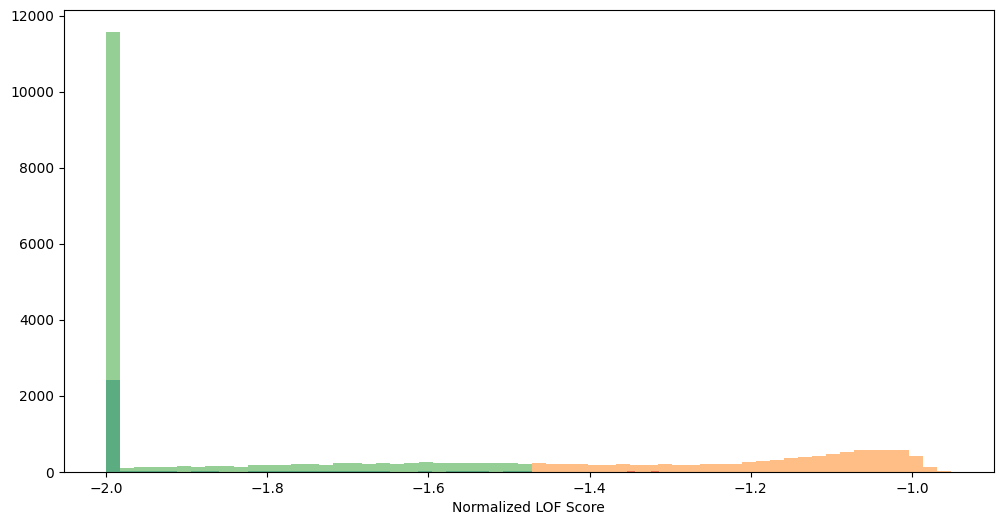

In [30]:
## ve distribution cua score cua LOF tren cac tap true positives, false positives, true negatives, false negatives
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.hist(lof_score_norm[(lof_predictions == 1) & (test_label[0] == 1)], bins=30, alpha=0.5, label='True Positives')
plt.hist(lof_score_norm[(lof_predictions == 0) & (test_label[0] == 0)], bins=30, alpha=0.5, label='True Negatives')
plt.hist(lof_score_norm[(lof_predictions == 1) & (test_label[0] == 0)], bins=30, alpha=0.5, label='False Positives')
plt.hist(lof_score_norm[(lof_predictions == 0) & (test_label[0] == 1)], bins=30, alpha=0.5, label='False Negatives')
plt.xlabel('Normalized LOF Score')

## Root cause analysis

In [49]:
anomaly_lof = test_data[lof_predictions_thresholded == 1]

print("Number of anomalies detected by LOF with threshold: ", len(anomaly_lof))
anomaly_lof.head(2)

Number of anomalies detected by LOF with threshold:  1424


,cpu_r,load_1,load_5,load_15,mem_shmem,mem_u,mem_u_e,total_mem,disk_q,disk_r,...,listen_overflows,out_rsts,out_segs,passive_opens,retransegs,tcp_timeouts,udp_in_dg,udp_out_dg,udp_rcv_buf_errs,udp_snd_buf_errs
968,0.129032,0.167373,0.125975,0.102207,0.0,0.923077,0.283427,0.0,0.028669,0.000000,...,0.0,0.014327,0.115361,0.095214,0.000773,0.000427,0.119163,0.119227,0.0,0.0
1485,0.086022,0.084746,0.079153,0.069686,0.0,0.915385,0.286252,0.0,0.033210,0.000244,...,0.0,0.008596,0.067283,0.046835,0.001159,0.000731,0.063274,0.063342,0.0,0.0


In [50]:
anomaly_if = test_data[isolation_forest_predictions == 1]

print("Number of anomalies detected by Isolation Forest: ", len(anomaly_if))
anomaly_if.head(2)

Number of anomalies detected by Isolation Forest:  3711


,cpu_r,load_1,load_5,load_15,mem_shmem,mem_u,mem_u_e,total_mem,disk_q,disk_r,...,listen_overflows,out_rsts,out_segs,passive_opens,retransegs,tcp_timeouts,udp_in_dg,udp_out_dg,udp_rcv_buf_errs,udp_snd_buf_errs
240,0.204301,0.277542,0.206243,0.190476,0.0,0.966667,0.276836,0.0,0.037468,0.000244,...,0.0,0.010029,0.152988,0.065878,0.000386,0.000045,0.223992,0.223976,0.0,0.0
244,0.247312,0.154661,0.167224,0.176539,0.0,0.976923,0.283427,0.0,0.038603,0.000122,...,0.0,0.010029,0.203787,0.124035,0.000386,0.000034,0.220445,0.220501,0.0,0.0


### get top 50 scores of LOF

In [51]:
top_50_lof_indices = np.argsort(lof_scores)[:50]
top_50_lof_data = test_data.iloc[top_50_lof_indices]

true_label_50_lof = test_label.iloc[top_50_lof_indices]
print("Precision of top 50 LOF: ", precision_score(true_label_50_lof, np.ones_like(true_label_50_lof)))

top_50_lof_data.head(2)

Precision of top 50 LOF:  0.98


,cpu_r,load_1,load_5,load_15,mem_shmem,mem_u,mem_u_e,total_mem,disk_q,disk_r,...,listen_overflows,out_rsts,out_segs,passive_opens,retransegs,tcp_timeouts,udp_in_dg,udp_out_dg,udp_rcv_buf_errs,udp_snd_buf_errs
17489,0.989247,0.929025,0.988852,0.995354,0.0,1.0,1.0,0.0,0.069543,0.000244,...,1.000000,0.694842,0.982347,1.00000,1.000000,1.000000,0.906972,0.906978,0.0,0.0
17486,0.978495,0.977754,0.997770,0.991870,0.0,1.0,1.0,0.0,0.097360,0.000000,...,0.850921,0.554441,0.975737,0.73649,0.901855,0.878604,0.984001,0.984002,0.0,0.0


### Compare to distribution of train data    

Note: Due to no information of label in training data -> can have 2 approach:  
- Assume all training data is normal 
- Apply Isolation forest to train, drop top 1-5% highest score -> then calculate (this way called more robust)    



In [52]:
training_data.describe()

,cpu_r,load_1,load_5,load_15,mem_shmem,mem_u,mem_u_e,total_mem,disk_q,disk_r,...,listen_overflows,out_rsts,out_segs,passive_opens,retransegs,tcp_timeouts,udp_in_dg,udp_out_dg,udp_rcv_buf_errs,udp_snd_buf_errs
count,28479.000000,28479.000000,28479.000000,28479.000000,28479.0,28479.000000,28479.000000,28479.0,28479.000000,28479.000000,...,28479.0,28479.000000,28479.000000,28479.000000,28479.000000,28479.000000,28479.000000,28479.000000,28479.0,28479.0
mean,0.064195,0.056882,0.053549,0.050188,0.0,0.913552,0.262274,0.0,0.020346,0.000159,...,0.0,0.005501,0.047294,0.036172,0.000188,0.000033,0.050351,0.050401,0.0,0.0
std,0.056685,0.042516,0.037695,0.037443,0.0,0.037972,0.066661,0.0,0.009982,0.001287,...,0.0,0.002545,0.033065,0.023716,0.000201,0.000015,0.035048,0.035044,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.006146,0.006691,0.000000,0.000000,0.008760,0.008759,0.0,0.0
25%,0.032258,0.027542,0.027871,0.024390,0.0,0.907692,0.251412,0.0,0.012347,0.000000,...,0.0,0.004298,0.026128,0.021101,0.000000,0.000022,0.027945,0.028015,0.0,0.0
50%,0.043011,0.045551,0.042363,0.037166,0.0,0.912821,0.274011,0.0,0.021005,0.000000,...,0.0,0.004298,0.034858,0.027792,0.000000,0.000034,0.036415,0.036485,0.0,0.0
75%,0.086022,0.075212,0.070234,0.067364,0.0,0.920513,0.311676,0.0,0.027959,0.000122,...,0.0,0.007163,0.062250,0.044261,0.000386,0.000045,0.066025,0.066020,0.0,0.0
max,0.494624,0.421610,0.278707,0.250871,0.0,1.000000,0.360640,0.0,0.118081,0.140435,...,0.0,0.028653,0.275407,0.303139,0.002318,0.001271,0.311229,0.311206,0.0,0.0


In [74]:
mean_training = training_data.mean()
std_training = training_data.std()
median_training = training_data.median()

median_training

cpu_r               0.043011
load_1              0.045551
load_5              0.042363
load_15             0.037166
mem_shmem           0.000000
mem_u               0.912821
mem_u_e             0.274011
total_mem           0.000000
disk_q              0.021005
disk_r              0.000000
disk_rb             0.126349
disk_svc            0.094595
disk_u              0.027397
disk_w              0.049979
disk_wa             0.096908
disk_wb             0.142122
si                  0.000000
so                  0.000000
eth1_fi             0.068516
eth1_fo             0.047862
eth1_pi             0.050059
eth1_po             0.037595
tcp_tw              0.667337
tcp_use             0.010160
active_opens        0.014518
curr_estab          0.009332
in_errs             0.000000
in_segs             0.041570
listen_overflows    0.000000
out_rsts            0.004298
out_segs            0.034858
passive_opens       0.027792
retransegs          0.000000
tcp_timeouts        0.000034
udp_in_dg     

In [73]:
temp_res = {}

for points in top_50_lof_data.iterrows():
    # print(points)
    ## point[0] is index, point[1] is the row data
    print(f"Processing point index {points[0]}")

    temp_score = {}
    for col in training_data.columns:
        
        value = points[1][col]
        mean = mean_training[col]
        # this use median instead of mean to be more robust to outliers in training data
        # median = median_training[col]
        std = std_training[col]
        if std > 0:
            # z_score = (value - median) / std
            z_score = (value - mean) / std
            if abs(z_score) >= 10:
                print(f"Feature {col} has z-score {z_score:.2f} for point index {points[0]}")
                pass
            temp_score[col] = abs(z_score)
        else:
            print(f"Feature {col} has std 0 in training data, skipping z-score calculation for point index {points[0]}")
            temp_score[col] = 0

        ## find max z-score feature for this point
        z_score_max_feature = max(temp_score, key=temp_score.get)
        z_score_max_value = temp_score[z_score_max_feature]

        # print(f"Max z-score feature for point index {points[0]} is {max_z_score_feature} with z-score {z_scores[max_z_score_feature]:.2f}")
    print("==" * 20)

    temp_res[points[0]] = {
        'max_z_score_feature': z_score_max_feature,
        'max_z_score': z_score_max_value
    }


temp_res_df = pd.DataFrame.from_dict(temp_res, orient='index')
print(temp_res_df.shape)
temp_res_df.head(10)

Processing point index 17489
Feature cpu_r has z-score 16.32 for point index 17489
Feature load_1 has z-score 20.51 for point index 17489
Feature load_5 has z-score 24.81 for point index 17489
Feature load_15 has z-score 25.24 for point index 17489
Feature mem_shmem has std 0 in training data, skipping z-score calculation for point index 17489
Feature mem_u_e has z-score 11.07 for point index 17489
Feature total_mem has std 0 in training data, skipping z-score calculation for point index 17489
Feature si has std 0 in training data, skipping z-score calculation for point index 17489
Feature so has std 0 in training data, skipping z-score calculation for point index 17489
Feature eth1_fi has z-score 16.12 for point index 17489
Feature eth1_fo has z-score 20.61 for point index 17489
Feature eth1_pi has z-score 21.93 for point index 17489
Feature eth1_po has z-score 26.02 for point index 17489
Feature tcp_use has z-score 169.22 for point index 17489
Feature active_opens has z-score 54.81 f

,max_z_score_feature,max_z_score
17489,tcp_timeouts,68129.658019
17486,tcp_timeouts,59858.721004
17485,tcp_timeouts,59055.854997
17484,tcp_timeouts,56972.995467
17482,tcp_timeouts,55855.360200
17483,tcp_timeouts,55624.801937
17487,tcp_timeouts,54869.423847
17490,tcp_timeouts,53564.085267
17478,tcp_timeouts,53074.625881
17488,tcp_timeouts,53062.362144


In [72]:
temp_res_df['max_z_score_feature'].value_counts()

max_z_score_feature
tcp_timeouts    50
Name: count, dtype: int64

All return tcp_timeouts is easy to recognize it as anomaly feature.   
So I need to get back to check if any hidden problem here

In [75]:
training_data['tcp_timeouts'].describe()

count    28479.000000
mean         0.000033
std          0.000015
min          0.000000
25%          0.000022
50%          0.000034
75%          0.000045
max          0.001271
Name: tcp_timeouts, dtype: float64

In [ ]:
import numpy as np
import pandas as pd

def calculate_psi(expected, actual, bins=10):
    # Create bins based on expected data
    breakpoints = np.percentile(expected, np.arange(0, 100 + 100 / bins, 100 / bins))
    
    # Bucketize data
    expected_bins = np.histogram(expected, bins=breakpoints)[0]
    actual_bins = np.histogram(actual, bins=breakpoints)[0]
    
    # Convert to proportions
    expected_perc = expected_bins / len(expected)
    actual_perc = actual_bins / len(actual)
    
    # Avoid division by zero
    expected_perc = np.where(expected_perc == 0, 0.0001, expected_perc)
    actual_perc = np.where(actual_perc == 0, 0.0001, actual_perc)
    
    # Calculate PSI
    psi = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))
    
    return psi

In [ ]:
calculate_psi(training_data['tcp_timeouts'], test_data['tcp_timeouts'], bins=10)

## Check PSI function - for future use

In [22]:
import numpy as np
import pandas as pd

def calculate_psi(expected, actual, bins=10):
    # Create bins based on expected data
    breakpoints = np.percentile(expected, np.arange(0, 100 + 100 / bins, 100 / bins))
    
    # Bucketize data
    expected_bins = np.histogram(expected, bins=breakpoints)[0]
    actual_bins = np.histogram(actual, bins=breakpoints)[0]
    
    # Convert to proportions
    expected_perc = expected_bins / len(expected)
    actual_perc = actual_bins / len(actual)
    
    # Avoid division by zero
    expected_perc = np.where(expected_perc == 0, 0.0001, expected_perc)
    actual_perc = np.where(actual_perc == 0, 0.0001, actual_perc)
    
    # Calculate PSI
    psi = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))
    
    return psi

In [23]:
train_data = np.random.normal(0, 1, 1000)
prod_data = np.random.normal(0.5, 1.2, 1000)

psi_value = calculate_psi(train_data, prod_data)

print("PSI:", psi_value)

PSI: 0.2051260801055139


In [24]:
psi_value

np.float64(0.2051260801055139)